# Step 3 - Keypoint / Pose Estimation 

In [38]:

%pip install ultralytics opencv-python-headless pandas matplotlib --quiet

import os, time, cv2, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from collections import defaultdict

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'd:\\MSc\\DS 5216 - Artificial Intelligence\\PAS02_DTS2430\\Code_PAS02\\.venv\\Lib\\site-packages\\cv2\\cv2.pyd'
Check the permissions.



In [3]:


VIDEO_FOLDER  = r'D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\Football'
OUTPUT_FOLDER  = r'D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\Football\output_keypoints'
SCREENSHOT_DIR = r'D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\Football\screenshots'


VIDEO_MAP = {
    'Football 01.mp4': 'Football',
    'Football 02.mp4': 'Football',
    'Football 03.mp4': 'Football',
    'Football 04.mp4': 'Football',
    'Football 05.mp4': 'Football',
    'Football 06.mp4': 'Football',
    'Football 07.mp4': 'Football',
    'Football 08.mp4': 'Football',
    'Football 09.mp4': 'Football',
    'Football 10.mp4': 'Football',
    'Football 11.mp4': 'Football',
    'Football 12.mp4': 'Football',
}

CONF_THRESHOLD = 0.30   
KP_THRESHOLD   = 0.40  
FRAME_SKIP     = 2      

os.makedirs(OUTPUT_FOLDER,  exist_ok=True)
os.makedirs(SCREENSHOT_DIR, exist_ok=True)

In [5]:
pose_model = YOLO('yolov8n-pose.pt')   
print(f'Model loaded - yolov8n-pose.pt')   

Model loaded - yolov8n-pose.pt


In [6]:

SKELETON = [
    (0,  1),  (0,  2),  
    (1,  3),  (2,  4),  
    (5,  6),            
    (5,  7),  (7,  9), 
    (6,  8),  (8, 10),   
    (5, 11),  (6, 12),   
    (11, 12),            
    (11, 13), (13, 15), 
    (12, 14), (14, 16),  
]

LIMB_COLORS = {
    (0,1):(255,200,0), (0,2):(255,200,0), (1,3):(255,200,0), (2,4):(255,200,0),
    (5,6):(0,200,255),
    (5,7):(0,255,80),  (7,9):(0,255,80),
    (6,8):(255,80,0),  (8,10):(255,80,0),
    (5,11):(180,0,255),(6,12):(180,0,255),(11,12):(180,0,255),
    (11,13):(0,180,255),(13,15):(0,180,255),
    (12,14):(255,0,180),(14,16):(255,0,180),
}

def draw_skeleton(frame, kps, kp_scores, threshold=0.4):
  
    
    for (i, j) in SKELETON:
        if kp_scores[i] > threshold and kp_scores[j] > threshold:
            pt1 = (int(kps[i][0]), int(kps[i][1]))
            pt2 = (int(kps[j][0]), int(kps[j][1]))
            color = LIMB_COLORS.get((i, j), (200, 200, 200))
            cv2.line(frame, pt1, pt2, color, 2, cv2.LINE_AA)

    for idx, (x, y) in enumerate(kps):
        if kp_scores[idx] > threshold:
            cv2.circle(frame, (int(x), int(y)), 4, (255, 255, 255), -1, cv2.LINE_AA)
            cv2.circle(frame, (int(x), int(y)), 3, (0,   0,   200), -1, cv2.LINE_AA)

In [8]:
def process_pose_video(filename, sport):
   
    video_path  = os.path.join(VIDEO_FOLDER, filename)
    output_path = os.path.join(OUTPUT_FOLDER, f'pose_{filename}')

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f'  ERROR: cannot open {video_path}')
        return None

    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    FPS   = cap.get(cv2.CAP_PROP_FPS)
    TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        FPS, (W, H)
    )

    metrics         = []
    last_result     = None
    screenshot_done = False
    fi = 0
    t0 = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        canvas = frame.copy()

        if fi % FRAME_SKIP == 0:
            results     = pose_model(
                frame,
                conf    = CONF_THRESHOLD,
                verbose = False
            )
            last_result = results[0]

        person_count  = 0
        total_kp_visible = 0

        if last_result is not None:
            boxes = last_result.boxes
            kp_data = last_result.keypoints  # shape: (N, 17, 3) → x, y, conf

            if boxes is not None and kp_data is not None:
                kp_xy  = kp_data.xy.cpu().numpy()    # (N, 17, 2)
                kp_conf= kp_data.conf.cpu().numpy()  # (N, 17)

                for i, (box, kps, kp_scores) in enumerate(
                    zip(boxes.xyxy.cpu().numpy().astype(int), kp_xy, kp_conf)
                ):
                    x1, y1, x2, y2 = box

                    cv2.rectangle(canvas, (x1,y1), (x2,y2), (0, 200, 255), 2)

                    label = f'P{i+1}'
                    (tw, th), _ = cv2.getTextSize(
                        label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                    cv2.rectangle(canvas, (x1, y1-th-8), (x1+tw+6, y1), (0,200,255), -1)
                    cv2.putText(canvas, label, (x1+3, y1-4),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                                (0, 0, 0), 1, cv2.LINE_AA)

                    draw_skeleton(canvas, kps, kp_scores, KP_THRESHOLD)

                    person_count     += 1
                    total_kp_visible += int(np.sum(kp_scores > KP_THRESHOLD))

        avg_kp = total_kp_visible / person_count if person_count > 0 else 0.0

        hud = (f'{sport}  |  Frame {fi}/{TOTAL}  |'
               f'  Persons: {person_count}  |  Avg KP visible: {avg_kp:.1f}/17')
        cv2.putText(canvas, hud, (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.60, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(canvas, hud, (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.60, (0,0,0),       1, cv2.LINE_AA)

        writer.write(canvas)

        if fi == 20 and not screenshot_done:
            ss_path = os.path.join(
                SCREENSHOT_DIR,
                f'{sport}_{filename.replace(" ","_")}_pose.jpg'
            )
            cv2.imwrite(ss_path, canvas)
            screenshot_done = True
            print(f'  Screenshot saved: {ss_path}')

        metrics.append({
            'frame'       : fi,
            'sport'       : sport,
            'filename'    : filename,
            'persons'     : person_count,
            'avg_kp_visible': avg_kp,
        })
        fi += 1

    cap.release()
    writer.release()

    elapsed = time.time() - t0
    avg_p   = np.mean([m['persons'] for m in metrics])
    avg_kp  = np.mean([m['avg_kp_visible'] for m in metrics if m['avg_kp_visible'] > 0])
    print(f'  Done  {fi} frames | {elapsed:.1f}s '
          f'| avg persons: {avg_p:.2f} | avg KP: {avg_kp:.2f}/17')

    return pd.DataFrame(metrics)

In [9]:
all_pose_metrics = {}

for filename, sport in VIDEO_MAP.items():
    path = os.path.join(VIDEO_FOLDER, filename)
    if not os.path.exists(path):
        print(f'SKIP (not found): {filename}')
        continue

    print(f'\n[{sport}] {filename}')
    df = process_pose_video(filename, sport)
    if df is not None:
        all_pose_metrics[filename] = df


[Football] Football 01.mp4
  Screenshot saved: D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\Football\screenshots\Football_Football_01.mp4_pose.jpg
  Done  311 frames | 11.0s | avg persons: 0.93 | avg KP: 14.22/17

[Football] Football 02.mp4
  Screenshot saved: D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\Football\screenshots\Football_Football_02.mp4_pose.jpg
  Done  311 frames | 20.3s | avg persons: 1.42 | avg KP: 12.49/17

[Football] Football 03.mp4
  Screenshot saved: D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\Football\screenshots\Football_Football_03.mp4_pose.jpg
  Done  301 frames | 22.4s | avg persons: 0.85 | avg KP: 12.57/17

[Football] Football 04.mp4
  Screenshot saved: D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\Football\screenshots\Football_Football_04.mp4_pose.jpg
  Done  309 frames | 22.4s | avg persons: 0.32 | avg KP: 14.60/17

[Football] Football 05.mp4
  Screenshot saved: D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\F

In [11]:
combined = pd.concat(all_pose_metrics.values(), ignore_index=True)

summary = (
    combined
    .groupby([ 'filename'])
    .agg(
        avg_persons      = ('persons',         'mean'),
        max_persons      = ('persons',         'max'),
        avg_kp_visible   = ('avg_kp_visible',  'mean'),
        total_frames     = ('frame',           'count'),
    )
    .round(3)
    .reset_index()
)

print('Keypoint Estimation Summary:')
print(summary.to_string(index=False))

csv_out = os.path.join(OUTPUT_FOLDER, 'keypoint_summary.csv')
summary.to_csv(csv_out, index=False)

Keypoint Estimation Summary:
       filename  avg_persons  max_persons  avg_kp_visible  total_frames
Football 01.mp4        0.932            3           9.783           311
Football 02.mp4        1.424            5          10.482           311
Football 03.mp4        0.850            3           6.598           301
Football 04.mp4        0.320            2           3.828           309
Football 05.mp4        1.120            4           9.719           301
Football 06.mp4        0.724            5           6.053           301
Football 07.mp4        0.572            2           4.280           304
Football 08.mp4        0.656            3           6.666           302
Football 09.mp4        0.890            3           6.818           301
Football 10.mp4        0.480            4           2.550           304
Football 11.mp4        2.140            7          10.509           301
Football 12.mp4        1.177            9           6.029           293


In [13]:
!pip install seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


C:\Users\USER\AppData\Local\Temp\ipykernel_30200\1073434592.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


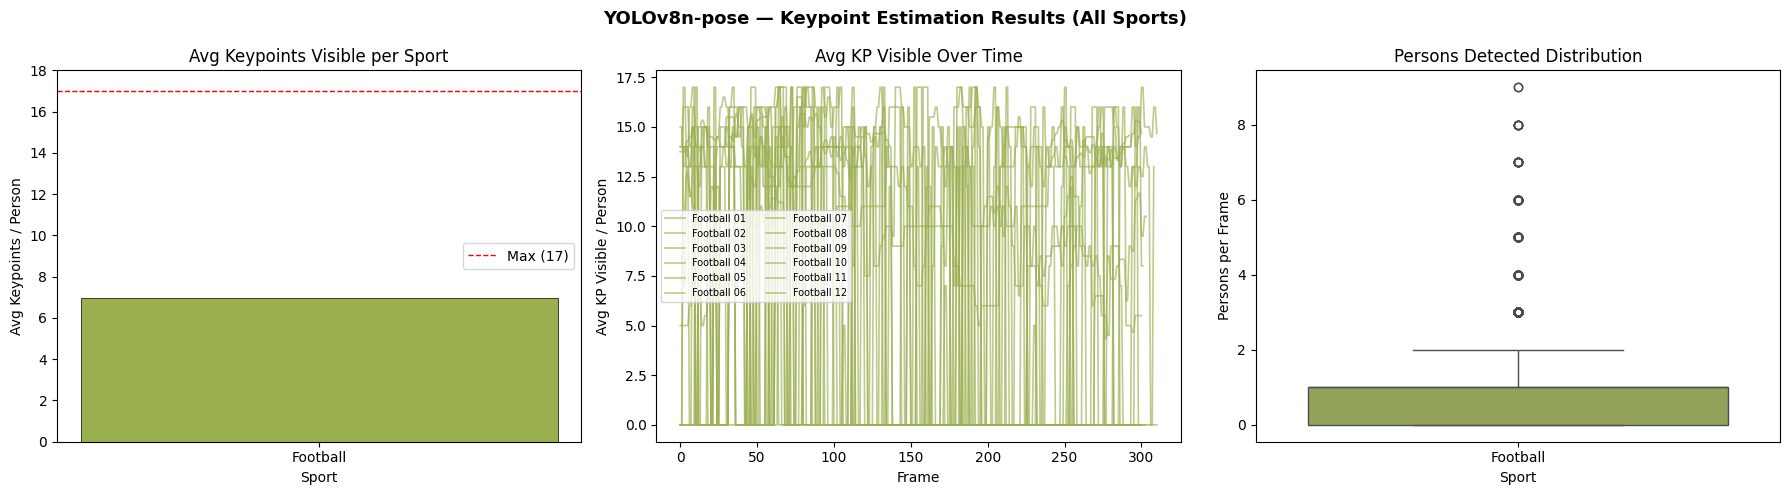

In [17]:
sport_colors = {'Football':'#9AAF50'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'YOLOv8n-pose — Keypoint Estimation Results (All Sports)',
    fontsize=13, fontweight='bold'
)

sport_kp = combined.groupby('sport')['avg_kp_visible'].mean().reset_index()
axes[0].bar(
    sport_kp['sport'], sport_kp['avg_kp_visible'],
    color=[sport_colors[s] for s in sport_kp['sport']],
    edgecolor='black', linewidth=0.5, width=0.45
)
axes[0].axhline(17, color='red', linestyle='--', linewidth=1, label='Max (17)')
axes[0].set_title('Avg Keypoints Visible per Sport')
axes[0].set_xlabel('Sport')
axes[0].set_ylabel('Avg Keypoints / Person')
axes[0].set_ylim(0, 18)
axes[0].legend()

for fname, df in all_pose_metrics.items():
    sport = df['sport'].iloc[0]
    axes[1].plot(
        df['frame'], df['avg_kp_visible'],
        label=fname.replace('.mp4', ''),
        color=sport_colors[sport],
        alpha=0.65, linewidth=1.2
    )
axes[1].set_title('Avg KP Visible Over Time')
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('Avg KP Visible / Person')
axes[1].legend(fontsize=7, ncol=2)

import seaborn as sns
sns.boxplot(
    data=combined, x='sport', y='persons',
    palette=sport_colors, ax=axes[2]
)
axes[2].set_title('Persons Detected Distribution')
axes[2].set_xlabel('Sport')
axes[2].set_ylabel('Persons per Frame')

plt.tight_layout()
plot_out = os.path.join(OUTPUT_FOLDER, 'keypoint_results.png')
plt.savefig(plot_out, dpi=150, bbox_inches='tight')
plt.show()

Video: Football 01.mp4
Exists: True
Frames processed: 311
Frames with keypoints: 22

Video: Football 02.mp4
Exists: True
Frames processed: 311
Frames with keypoints: 26

Video: Football 03.mp4
Exists: True
Frames processed: 301
Frames with keypoints: 14

Video: Football 04.mp4
Exists: True
Frames processed: 309
Frames with keypoints: 8

Video: Football 05.mp4
Exists: True
Frames processed: 301
Frames with keypoints: 23

Video: Football 06.mp4
Exists: True
Frames processed: 301
Frames with keypoints: 13

Video: Football 07.mp4
Exists: True
Frames processed: 304
Frames with keypoints: 16

Video: Football 08.mp4
Exists: True
Frames processed: 302
Frames with keypoints: 14

Video: Football 09.mp4
Exists: True
Frames processed: 301
Frames with keypoints: 17

Video: Football 10.mp4
Exists: True
Frames processed: 304
Frames with keypoints: 8

Video: Football 11.mp4
Exists: True
Frames processed: 301
Frames with keypoints: 29

Video: Football 12.mp4
Exists: True
Frames processed: 293
Frames wi

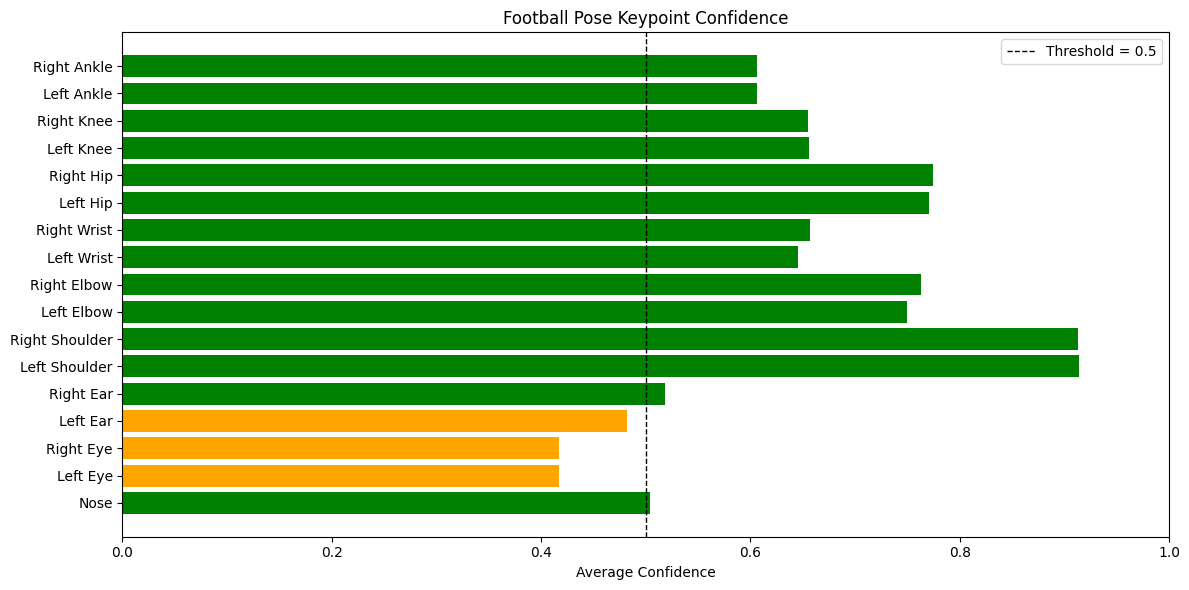


Saved: D:\MSc\DS 5216 - Artificial Intelligence\PAS02_DTS2430\Football\output_keypoints\per_keypoint_confidence.png

Ranking:
      Keypoint  Average Confidence
 Left Shoulder            0.914124
Right Shoulder            0.913219
     Right Hip            0.774286
      Left Hip            0.770505
   Right Elbow            0.763095
    Left Elbow            0.749432
   Right Wrist            0.657193
     Left Knee            0.655647
    Right Knee            0.655172
    Left Wrist            0.645270
    Left Ankle            0.606604
   Right Ankle            0.606510
     Right Ear            0.518027
          Nose            0.503658
      Left Ear            0.482000
      Left Eye            0.417553
     Right Eye            0.417157


In [37]:
KP_NAMES = [
    'Nose','Left Eye','Right Eye','Left Ear','Right Ear',
    'Left Shoulder','Right Shoulder',
    'Left Elbow','Right Elbow',
    'Left Wrist','Right Wrist',
    'Left Hip','Right Hip',
    'Left Knee','Right Knee',
    'Left Ankle','Right Ankle'
]

kp_conf_accumulator = np.zeros(17)
kp_count = 0
for filename, sport in VIDEO_MAP.items():

    video_path = os.path.join(VIDEO_FOLDER, filename)

    print(f"Video: {filename}")
    print(f"Exists: {os.path.exists(video_path)}")

    if not os.path.exists(video_path):
        print("SKIPPED\n")
        continue

    cap = cv2.VideoCapture(video_path)

    frame_count = 0
    detection_count = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % (FRAME_SKIP * 5) == 0:

            results = pose_model(
                frame,
                conf=CONF_THRESHOLD,
                verbose=False
            )

            if results[0].keypoints is not None:

                kp_data = results[0].keypoints

                if kp_data.conf is not None:

                    scores = kp_data.conf.cpu().numpy()

                    if len(scores) > 0:

                        kp_conf_accumulator += scores.mean(axis=0)

                        kp_count += 1
                        detection_count += 1

        frame_count += 1

    cap.release()

    print(f"Frames processed: {frame_count}")
    print(f"Frames with keypoints: {detection_count}")
    print()

print("\nTotal keypoint frames:", kp_count)

if kp_count > 0:

    avg_kp_conf = kp_conf_accumulator / kp_count

    print("\nAverage confidence per keypoint:")
    print(avg_kp_conf)

    fig, ax = plt.subplots(figsize=(12, 6))

    colors = [
        'green' if c >= 0.5 else 'orange'
        for c in avg_kp_conf
    ]

    ax.barh(
        KP_NAMES,
        avg_kp_conf,
        color=colors
    )

    ax.axvline(
        0.5,
        linestyle='--',
        linewidth=1,
        color='black',
        label='Threshold = 0.5'
    )

    ax.set_xlim(0, 1)
    ax.set_xlabel("Average Confidence")
    ax.set_title("Football Pose Keypoint Confidence")

    ax.legend()

    plt.tight_layout()

    kp_plot = os.path.join(
        OUTPUT_FOLDER,
        "per_keypoint_confidence.png"
    )

    plt.savefig(
        kp_plot,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("\nSaved:", kp_plot)

    kp_df = pd.DataFrame({
        "Keypoint": KP_NAMES,
        "Average Confidence": avg_kp_conf
    })

    print("\nRanking:")
    print(
        kp_df.sort_values(
            "Average Confidence",
            ascending=False
        ).to_string(index=False)
    )

else:

    print("\nNo keypoints collected.")

Video -  Football 04.mp4


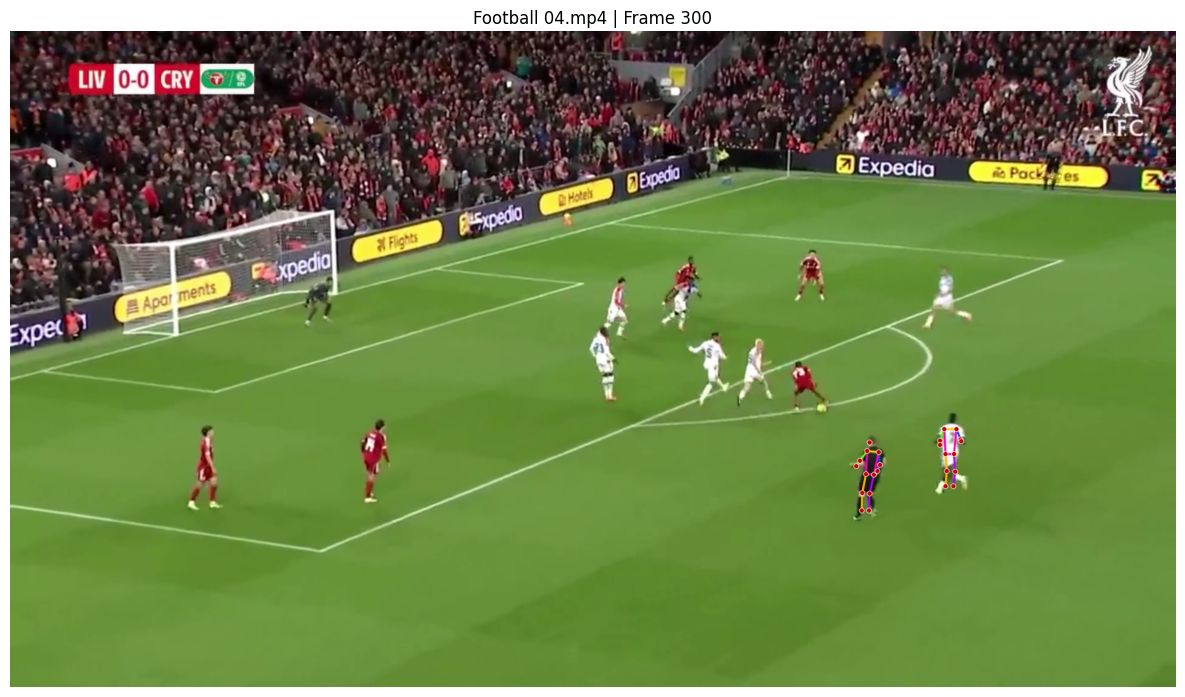

Persons detected -  2


In [ ]:
TEST_VIDEO = "Football 04.mp4"   
TEST_FRAME = 300              

TEST_PATH = os.path.join(VIDEO_FOLDER, TEST_VIDEO)

print("Video - ", TEST_VIDEO)
cap = cv2.VideoCapture(TEST_PATH)

cap.set(cv2.CAP_PROP_POS_FRAMES, TEST_FRAME)

ret, frame = cap.read()

cap.release()

if ret:

    results = pose_model(
        frame,
        conf=CONF_THRESHOLD,
        verbose=False
    )

    canvas = frame.copy()

    kp_data = results[0].keypoints

    if kp_data is not None:

        kp_xy = kp_data.xy.cpu().numpy()

        if kp_data.conf is not None:
            kp_conf = kp_data.conf.cpu().numpy()

            for kps, kp_scores in zip(kp_xy, kp_conf):
                draw_skeleton(
                    canvas,
                    kps,
                    kp_scores,
                    KP_THRESHOLD
                )

    canvas_rgb = cv2.cvtColor(
        canvas,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(12, 7))
    plt.imshow(canvas_rgb)
    plt.title(
        f"{TEST_VIDEO} | Frame {TEST_FRAME}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Persons detected - ", len(results[0].boxes))

else:

    print("Could not read frame.")